   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

     age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.00      0      0   24160  211.3375       B5        S    2    NaN   
1   0.92      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.00      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St Louis, MO  


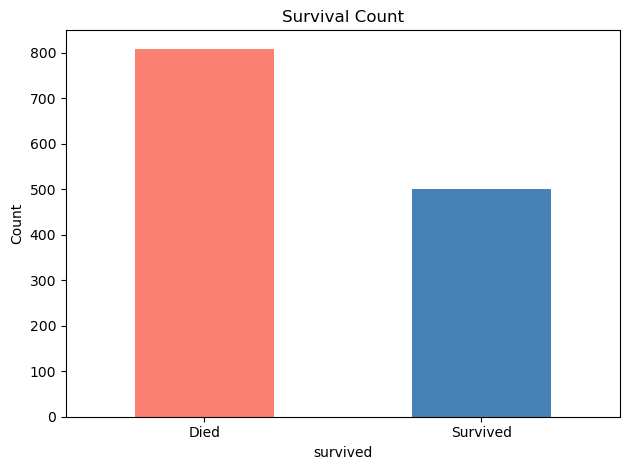

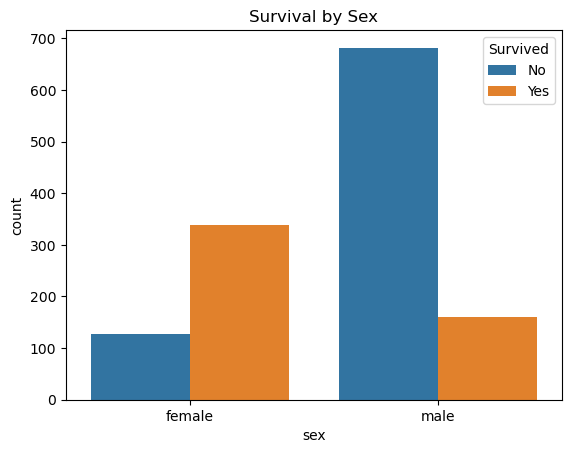

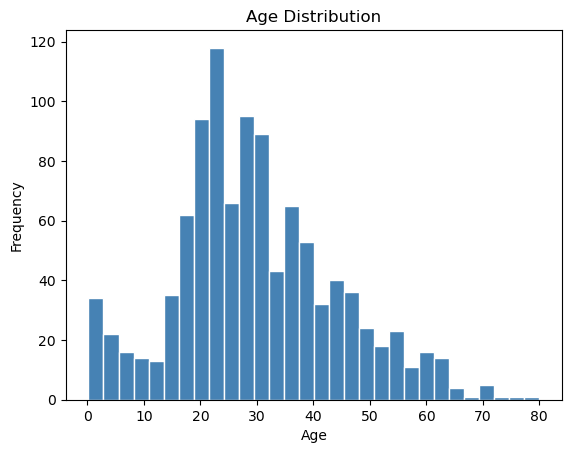

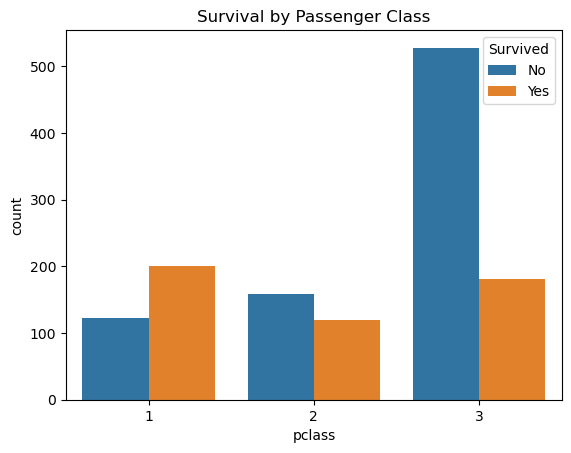


Missing values after cleaning:
pclass    0
sex       0
age       0
sibsp     0
parch     0
fare      1
dtype: int64

Dataset shape: (1309, 6)


/var/folders/5j/zqp_z0115jvdgljydhwjmtpm0000gn/T/ipykernel_52879/579471901.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,precision_score, recall_score,roc_curve, roc_auc_score)

df = pd.read_csv('titanic.csv')
print(df.head())
print(df.isnull().sum())

df['survived'].value_counts().plot(kind='bar', title='Survival Count', color=['salmon', 'steelblue'])
plt.xticks([0, 1], ['Died', 'Survived'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()
#0 is dead. 1 is survived. 

sns.countplot(data=df, x='sex', hue='survived')
plt.title('Survival by Sex')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()
#survival by sex plot

df['age'].dropna().plot(kind='hist', bins=30, title='Age Distribution', color='steelblue', edgecolor='white')
plt.xlabel('Age')
plt.show()
#age of passengers


sns.countplot(data=df, x='pclass', hue='survived')
plt.title('Survival by Passenger Class')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()
#survival count by passenger class

df['age'].fillna(df['age'].median(), inplace=True)
#place median age for missing age values.

df['sex'] = df['sex'].map({'male': 0, 'female': 1})
#male is 0. female is 1.

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
X = df[features]
y = df['survived']

print("\nMissing values after cleaning:")
print(X.isnull().sum())
print(f"\nDataset shape: {X.shape}")

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#random state 42 locks the shuffle order to random state 42

print(f"Training set size: {len(X_train)} passengers") 
print(f"Test set size:     {len(X_test)} passengers")



Training set size: 1047 passengers
Test set size:     262 passengers


In [53]:
dt_unlimited = DecisionTreeClassifier(random_state=42)
dt_unlimited.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_unlimited.predict(X_train))
test_acc  = accuracy_score(y_test,  dt_unlimited.predict(X_test))

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Training Accuracy: 0.969
Test Accuracy: 0.767


This is overfitting. With no depth limit, the tree grew deep enough to memorize every single passenger in the training data including random noise. It built hyper-specific rules that only work for those exact passengers. When it sees new passengers in the test set, those rules don't hold up, so accuracy drops sharply. The gap between training and test accuracy is the overfitting signal.

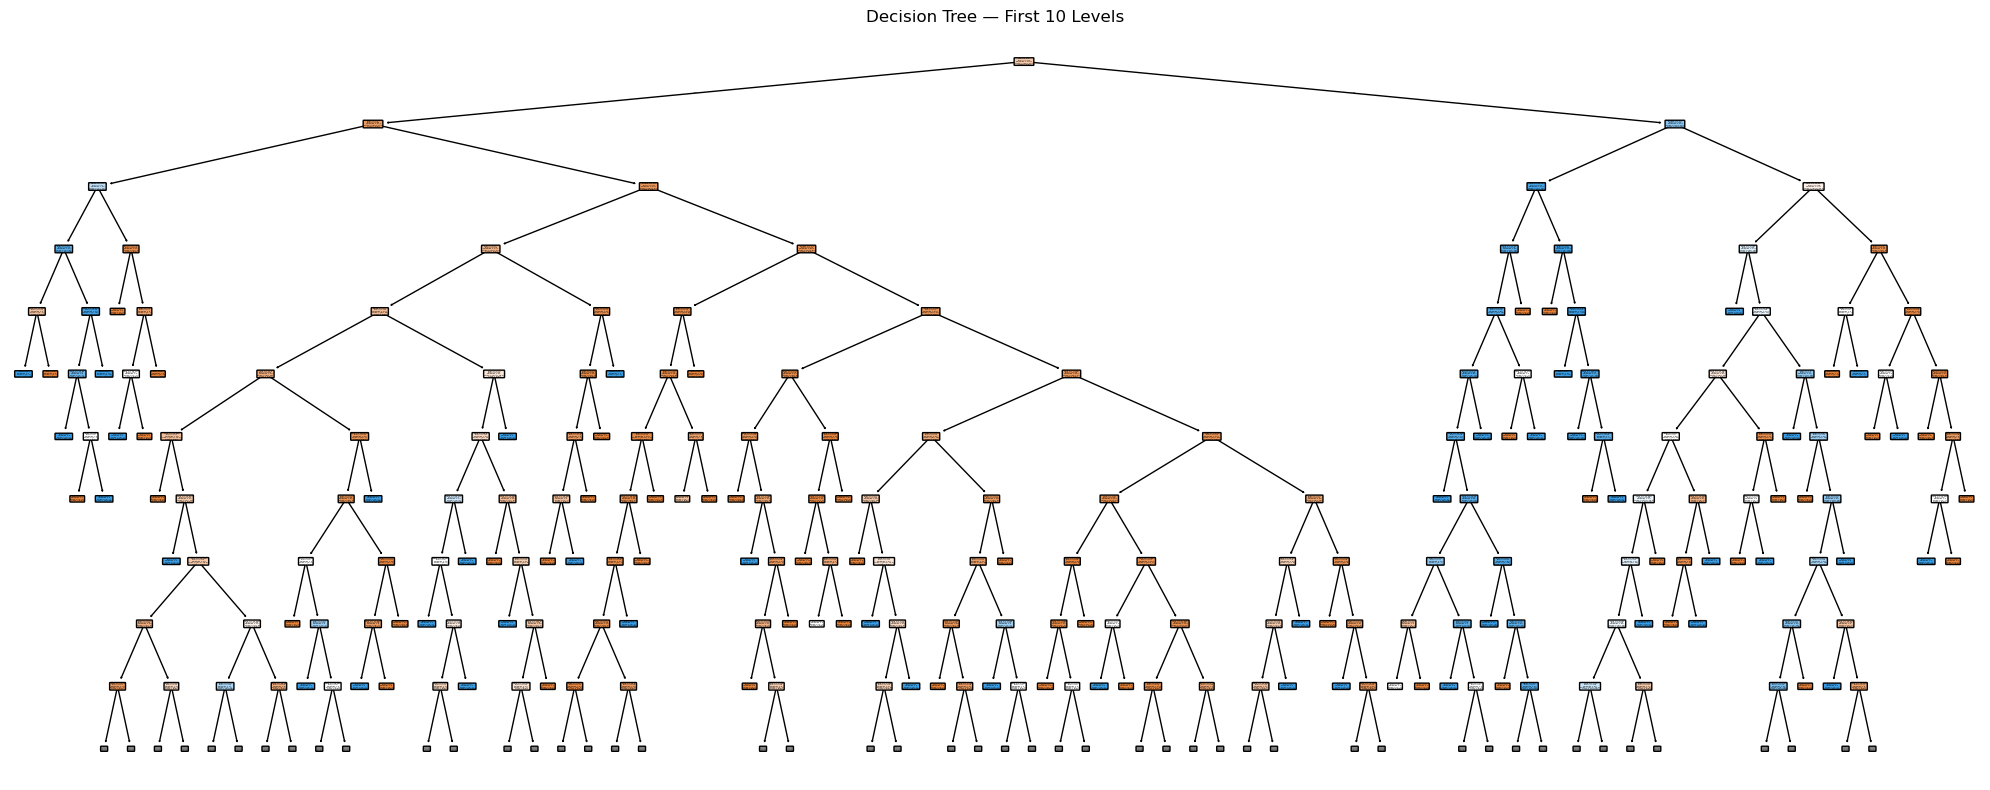

In [57]:
plt.figure(figsize=(20, 8))
plot_tree(dt_unlimited,
          max_depth=10,
          feature_names=features,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True)
plt.title("Decision Tree — First 10 Levels")
plt.tight_layout()
plt.show()

this makes sense because women and children were prioritized for evacuation. then it looked at passenger class (rich people) and age (children). this makes sense because rich people were more likely to survive than poor people. first class cabins were closer to lifeboats.

In [71]:
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

pruned_test_acc = accuracy_score(y_test, dt_pruned.predict(X_test))

print(f"Unlimited Tree Test Accuracy: {test_acc:.3f}")
print(f"Pruned Tree Test Accuracy:    {pruned_test_acc:.3f}")

Unlimited Tree Test Accuracy: 0.767
Pruned Tree Test Accuracy:    0.779


limiting depth allows computer not to memorizd but learn the actual pattern behind survival rates. this is represented by having less of a difference in accuracy score between train and test datasets.

In [72]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_test_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"Single Tree Test Accuracy:   {test_acc:.3f}")
print(f"Pruned Tree Test Accuracy:   {pruned_test_acc:.3f}")
print(f"Random Forest Test Accuracy: {rf_test_acc:.3f}")

Single Tree Test Accuracy:   0.767
Pruned Tree Test Accuracy:   0.779
Random Forest Test Accuracy: 0.782


the single tree is simple and interpretible for us humans. but, the random forest is more complex and less decipherable for us humans. the random forest is slightly better in this case.

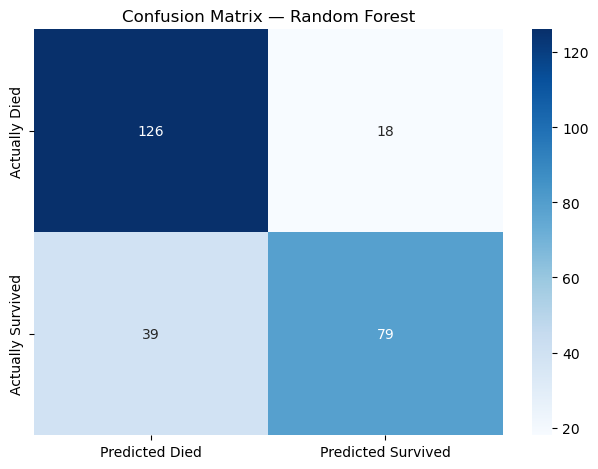

False Positives (predicted survived, actually died): 18
False Negatives (predicted died, actually survived): 39


In [73]:
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Died', 'Predicted Survived'],
            yticklabels=['Actually Died', 'Actually Survived'])
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

# Extract specific error counts
false_positives = cm[0][1]  # Predicted survived, actually died
false_negatives = cm[1][0]  # Predicted died, actually survived

print(f"False Positives (predicted survived, actually died): {false_positives}")
print(f"False Negatives (predicted died, actually survived): {false_negatives}")

False Positives are passengers who died but we predicted survied. FN is when we predict the passenger died but actually survived. we want to minimize false positives because having false hope is worse than a person who thought was dead being alive.


In [74]:
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")

Precision: 0.814
Recall:    0.669


precision is: out of the survivors we flagged, how many are actually survivors?
high precision is having high threshold`

recall is of people who actually survived, how many did we catch?
high recall is being less strict and marking more people as survivors.

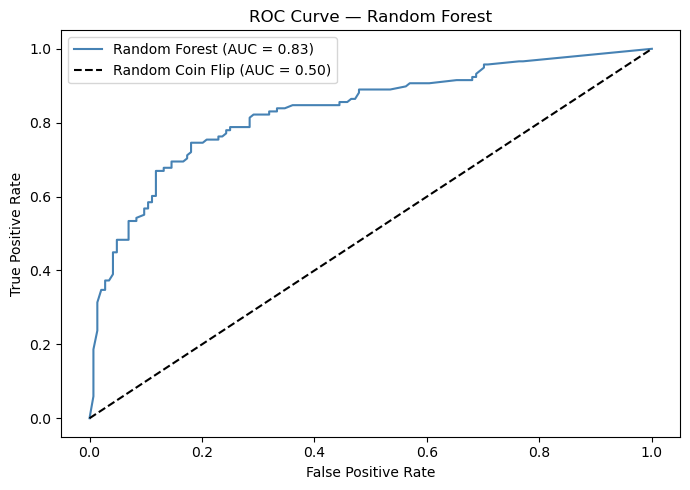

AUC Score: 0.832


In [76]:
y_proba = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f"Random Forest (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Coin Flip (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.3f}")

An AUC of 0.85 means if you randomly picked one passenger who survived and one who died, the model would correctly rank the survivor as "more likely to survive" 85% of the time. So 0.85 means the model is far better than chance at discriminating between survivors and victims. The closer AUC gets to 1.0, the more perfectly the model separates the two groups.

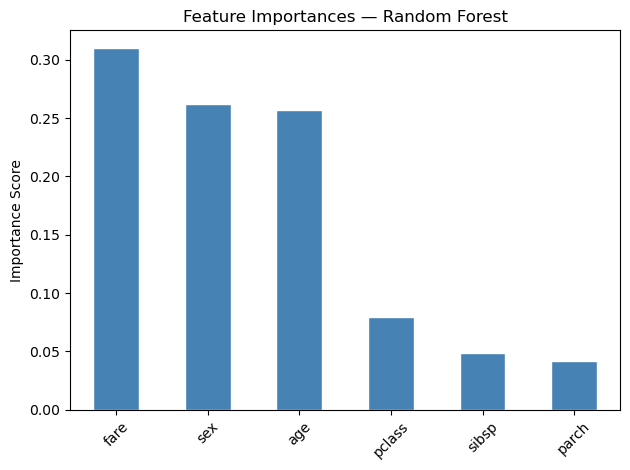

fare      0.309764
sex       0.262372
age       0.257393
pclass    0.079602
sibsp     0.048961
parch     0.041908
dtype: float64


In [77]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Feature Importances — Random Forest")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(importances)

1. fare
2. sex
3. age
the rest seems insignificant in this bar chart.